乳腺癌数据集
datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad
使用修改后的十个四元组

📂 一、 最终生成的文件清单 (Outputs)
你的代码会在指定的输出目录（outputs/Human_breast_cancer_ViHBC/）中生成以下两大类文件：
1. SpaCET 相关的基础指标文件夹 (zhibiao/SpaCET/)
🖼️ GMM_Malignant_Threshold_Plot.png：双峰高斯分布拟合图（完美解释你为何不切 0.5 而是自适应寻找阈值，可放论文 Supplementary）。
📊 GMM_Optimal_Threshold_Result.csv：记录了 GMM 算出来的具体最优阈值数值（如 0.4532）。
📊 GMM_Tumor_NonTumor_Pred_Labels.csv：仅包含 Spot ID、连续恶性分数和二分类预测标签的轻量级结果表。
2. 最终层级生态位文件夹 (Final_Hierarchical_Niches/)
🖼️ Hierarchical_Niche_Map.png：（如果取消注释）左图为 Level 1 宏观肿瘤/健康区域，右图为 Level 2 纯化后的代谢微生态位空间图（极具视觉冲击力的核心主图）。
📊 Level2_Niche_Counts.csv：（如果取消注释）每种代谢生态位（如乳酸轴、谷氨酰胺轴、休眠区等）所占的 Spot 数量统计，可直接用于画饼图或柱状图。
📊 ARI_Tumor_Segmentation_Result.csv：你的跨模态联合区域与病理医生金标准的 ARI 评估结果得分（证明模型准确性的黄金表格）。
🧬 Human_breast_cancer_ViHBC_TCMN_Final.h5ad：【最核心资产】 包含了原始基因矩阵、空间坐标、以及下面列出的所有极其丰富的 metadata 标签！

终极 h5ad 文件的核心信息列 (adata.obs)
当你未来在其他脚本中加载 adata = ad.read_h5ad("..._TCMN_Final.h5ad") 时，你的 adata.obs 就成了一座数据宝库。我将其分为 5 大逻辑模块：
🥇 模块 1：终极输出标签（你后续分析最常用的列）
列名 (adata.obs Columns)	含义与示例	用途
Level2_Micro_Niche	最终的纯化代谢微型生态位。示例：TMCN_Lactate_Axis（单轴）, TMCN_Glutamine_Lactate_Multi_Axis（多轴）, TMCN_Quiescent（死寂区）, Healthy_Region。	全篇论文的核心分组依据。后续画差异表达、小提琴图、细胞通讯弦图，全部基于这个列进行 groupby。
Level1_Macro_Region	宏观肿瘤微环境边界。示例：Tumor_Region，Healthy_Region。	用于比较全肿瘤内部与外部健康基质的宏观差异。
🥈 模块 2：你最新要求的“多轴活跃比例”（量化混合生态位特征）
对于 10 条轴的每一条，都有以下列（以 Lactate 为例）：
| 列名 | 含义与示例 | 用途 |
| :--- | :--- | :--- |
| Lactate_Cluster_Active_Frac | 本聚类内乳酸轴突破活跃阈值的 Spot 比例（0.0 ~ 1.0）。示例：0.85 | 极高价值！证明 Multi_Axis 生态位不是强行命名的，而是例如 乳酸=0.85 且 谷氨酰胺=0.62 真实双高并存的。可用此列画散点相关性图。 |
🥉 模块 3：连续生化特征与耦合打分（空间连续信号）
对于 10 条轴的每一条，都有以下列（以 Lactate 为例）：
| 列名 | 含义与示例 | 用途 |
| :--- | :--- | :--- |
| Lactate_Sender_Score | 自身发射能力 (PROGENy通路 × 代谢酶)。连续值 (01)。 | 用来画单一生化功能的空间热力渐变图。 |
| Lactate_Receiver_Score | 自身接收能力 (受体表达)。连续值 (01)。 | 同上。 |
| Coupling_Lactate | 真实空间通讯耦合分数 (Log1p(Sender × 物理邻居Receiver))。 | 最硬核的特征。反映该 Spot 正在经历多强的空间物质流动。是后续推断因果通讯权重（阶段五）的基础！ |
🏅 模块 4：跨模态基准标签（模型决策依据）
列名	含义与示例	用途
Malignant	SpaCET 原始输出的连续恶性比例（0~1）。	展示 SpaCET 原始视野。
Unsupervised_Pred_0.45	GMM自动阈值二分类（Predicted_Tumor / Non_Tumor）。	Level 1 宏观划界的基础之一。
annot_type	原始人工病理标注 (Tumor, Surrounding tumor...)	仅用于计算 ARI 和金标准对比对照，不参与我们无监督模型的生成逻辑，保证算法清白。
Ground_Truth_Binary	统一为 Tumor_Region / Non_Tumor_Region。	方便直接与 Level1_Macro_Region 做混淆矩阵分析。
🎖️ 模块 5：底层无监督拓扑结构（追溯使用）
列名	含义与示例	用途
latent_leiden_0.4	NicheCompass 跑出来的原始图神经聚类（如 0, 1, 2...）。	证明我们并没有改变算法底层的物理骨架。
Final_Niche_Type	平滑去噪后的初始代谢标签（未与 SpaCET 结合的纯代谢版本）。	可以用来对比“结合 SpaCET 前后”到底纠正了多少假阳性。
💡 总结：后续你可以怎么用这个 h5ad？
这个 h5ad 是一张完美标注的肿瘤生态位寻宝图。
如果你想验证多轴（Multi-axis）的生物学意义：
直接取子集：adata_multi = adata[adata.obs['Level2_Micro_Niche'] == 'TMCN_Glutamine_Lactate_Multi_Axis']
然后查看：adata_multi.obs[['Glutamine_Cluster_Active_Frac', 'Lactate_Cluster_Active_Frac']]，你会发现这两列的数值都非常高（>0.3），完美印证了微环境在这片区域同时进行着两套代谢途径。
如果你想进行下一步（阶段四：通讯推断）：
你可以直接调用 Coupling_{Axis} 列作为权重源，调用 Level2_Micro_Niche 作为节点分组（Node Type），毫无障碍地生成空间有向弦图（Chord diagram）或向量场图（Vector fields）。

In [ ]:
使用SpaCET得出spot反卷积结果和肿瘤非肿瘤标签

In [ ]:
# ===================== Cell 1 =====================
# ===================== 1. 导入必需库 =====================
import anndata as ad

# ===================== 2. 读取你的 h5ad 文件 =====================
# 你的文件完整路径（直接用，无需修改）
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad"

print("正在读取 h5ad 文件...")
adata = ad.read_h5ad(file_path)
print("文件读取成功！")
print("="*60)

# ===================== 3. 查看 基因名（核心！） =====================
print("【前 20 个基因名】：")
gene_names = adata.var.index.tolist()
print(gene_names[:20])
print("="*60)

# ===================== 4. 自动判断基因名格式 =====================
first_gene = gene_names[0]

if first_gene.startswith("ENSG"):
    print("❌ 检测结果：Ensembl ID 格式（例如 ENSG00000141510）")
    print("⚠️  警告：SpaCET 无法直接使用，需要转换为 Gene Symbol！")
else:
    print("✅ 检测结果：标准 Gene Symbol 格式（例如 TP53/ACTB）")
    print("🎉 完美！可以直接运行 SpaCET 代码，无需任何修改！")
    
import anndata as ad
import pandas as pd

# ==========================================
# 1. 设置文件路径
# ==========================================
# 你的原始 h5ad 文件路径
path_h5ad_original = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated.h5ad"

# 你的 SpaCET 结果 CSV 文件路径
path_spacet_csv = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/SpaCET_CellFractions_Result.csv"

# 输出文件路径（建议不要覆盖原文件，生成一个新的）
path_h5ad_output = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated_with_SpaCET.h5ad"

# ==========================================
# 2. 读取数据
# ==========================================
print("正在读取数据...")

# 读取原始 h5ad
adata = ad.read_h5ad(path_h5ad_original)

# 读取 SpaCET CSV
# 假设 CSV 的第一列是 Spot ID，我们将其设为 index
spacet_df = pd.read_csv(path_spacet_csv, index_col=0)

print(f"✅ 原始 h5ad 包含 {adata.n_obs} 个 Spots")
print(f"✅ SpaCET 结果包含 {spacet_df.shape[0]} 个 Spots")

# ==========================================
# 3. 【关键】检查并对齐 Spot ID
# ==========================================
# 这一步极其重要，防止因为 ID 不匹配导致数据错位
# 找出共同的 Spot ID
common_spots = adata.obs_names.intersection(spacet_df.index)

if len(common_spots) == 0:
    raise ValueError("❌ 错误：原始 h5ad 和 SpaCET 结果没有匹配的 Spot ID！请检查 CSV 的第一列是否为正确的 Spot 名称。")
elif len(common_spots) < adata.n_obs:
    print(f"⚠️  警告：有 {adata.n_obs - len(common_spots)} 个 Spots 在 SpaCET 结果中未找到（可能是在 SpaCET QC 步骤被过滤了）。")
    # 只保留共同的 Spots（可选，或者你选择保留所有，缺失值填 NA）
    # 这里我们选择只保留共同的，以保证数据完整性
    adata = adata[common_spots].copy()

# 重新排序 SpaCET 的 DataFrame，使其顺序与 h5ad 完全一致
spacet_df_aligned = spacet_df.reindex(adata.obs_names)

# ==========================================
# 4. 合并注入到 h5ad
# ==========================================
print("正在合并数据...")

# 将 SpaCET 的所有列合并到 adata.obs 中
# 为了防止列名冲突，可以给 SpaCET 的列加上前缀（可选，这里直接合并）
# spacet_df_aligned = spacet_df_aligned.add_prefix('SpaCET_') 

adata.obs = adata.obs.join(spacet_df_aligned)

print("✅ 合并完成！adata.obs 中新增了以下列：")
print(spacet_df_aligned.columns.tolist())

# ==========================================
# 5. 保存新的 h5ad 文件
# ==========================================
print(f"正在保存新文件至：{path_h5ad_output}")
adata.write_h5ad(path_h5ad_output)

print("🎉 全部完成！你现在可以在 Python 中加载新的 h5ad 文件进行后续分析了。")

SpaCET
使用GMM计算阈值
高斯混合模型 (Gaussian Mixture Model, GMM)：假设数据由“低分（非肿瘤）”和“高分（肿瘤）”两个正态分布混合而成，寻找两个分布概率相交的点作为阈值。（最推荐，能处理方差不同的分布）

In [ ]:
# ===================== Cell 1-1 =====================
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
import os  # 新增：用于创建文件夹/路径管理

# ==========================================
# 🔥 固定输出路径（你指定的文件夹）
# ==========================================
SAVE_DIR = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/SpaCET"
os.makedirs(SAVE_DIR, exist_ok=True)  # 自动创建文件夹，不存在则新建

# ==========================================
# 1. 读取数据
# ==========================================
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated_with_SpaCET.h5ad"
print("正在加载数据...")
adata = ad.read_h5ad(file_path)

# ==========================================
# 1. 提取 SpaCET 的 Malignant 分数
# ==========================================
# 过滤掉 NaN 值（如果有背景点）
malignant_scores = adata.obs['Malignant'].dropna().values
# GMM 要求输入是 2D 数组 (n_samples, 1)
X = malignant_scores.reshape(-1, 1)

# ==========================================
# 2. 使用 GMM (高斯混合模型) 自动寻找最优阈值
# ==========================================
print("正在使用高斯混合模型 (GMM) 拟合数据分布...")
# 假设数据分为 2 类（肿瘤 vs 非肿瘤）
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42)
gmm.fit(X)

# 找出两个分布的均值，区分哪个是非肿瘤(低均值)，哪个是肿瘤(高均值)
means = gmm.means_.flatten()
class_non_tumor_idx = np.argmin(means)
class_tumor_idx = np.argmax(means)

# 寻找两个正态分布交叉的边界点 (即最优阈值)
# 我们在两个均值之间生成 1000 个密集点，看哪一个点模型预测的分类发生了反转
x_test = np.linspace(means[class_non_tumor_idx], means[class_tumor_idx], 1000).reshape(-1, 1)
preds = gmm.predict(x_test)

# 找到分类反转的索引
flip_index = np.where(preds[:-1] != preds[1:])[0]

if len(flip_index) > 0:
    optimal_threshold = x_test[flip_index[0]][0]
else:
    # 极端情况下如果找不到交点，取两个均值的中间值
    optimal_threshold = np.mean(means)

print(f"✨ [无监督] 自动计算出的最优划分阈值为: {optimal_threshold:.4f}")

# ==========================================
# 3. 将新的划分应用到 adata 中
# ==========================================
col_name = f'Unsupervised_Pred_{optimal_threshold:.2f}'
adata.obs[col_name] = np.where(
    adata.obs['Malignant'] > optimal_threshold, 
    'Predicted_Tumor', 
    'Predicted_Non_Tumor'
)
adata.obs[col_name] = adata.obs[col_name].astype('category')

# ==========================================
# 4. 可视化：分布图 (解释为什么选这个阈值) + 空间图
# ==========================================
fig = plt.figure(figsize=(18, 5))

# -----------------
# 子图 1: 分数分布与 GMM 拟合曲线
# -----------------
ax1 = plt.subplot(1, 3, 1)
# 画直方图
sns.histplot(malignant_scores, bins=50, stat='density', alpha=0.5, color='gray', ax=ax1, label='Actual Data')

# 画 GMM 拟合出来的两个正态分布曲线
x_plot = np.linspace(0, 1, 1000).reshape(-1, 1)
logprob = gmm.score_samples(x_plot)
pdf = np.exp(logprob)
responsibilities = gmm.predict_proba(x_plot)

pdf_non_tumor = pdf * responsibilities[:, class_non_tumor_idx]
pdf_tumor = pdf * responsibilities[:, class_tumor_idx]

ax1.plot(x_plot, pdf_non_tumor, color='blue', label='Non-Tumor Distribution', lw=2)
ax1.plot(x_plot, pdf_tumor, color='red', label='Tumor Distribution', lw=2)

# 画阈值垂直线
ax1.axvline(optimal_threshold, color='green', linestyle='--', lw=2.5, 
            label=f'Optimal Threshold = {optimal_threshold:.2f}')

ax1.set_title('Malignant Fraction Distribution & GMM Fit')
ax1.set_xlabel('SpaCET Malignant Fraction')
ax1.set_ylabel('Density')
ax1.legend()

# -----------------
# 子图 2: SpaCET 连续分数的空间分布
# -----------------
ax2 = plt.subplot(1, 3, 2)
sc.pl.spatial(adata, color='Malignant', title='SpaCET Malignant Fraction', 
              spot_size=170, cmap='Reds', ax=ax2, show=False)

# -----------------
# 子图 3: 使用自动阈值划分后的离散空间分布
# -----------------
ax3 = plt.subplot(1, 3, 3)
sc.pl.spatial(adata, color=col_name, title=f'Unsupervised Classification\n(Threshold > {optimal_threshold:.2f})', 
              spot_size=170, ax=ax3, show=False)

plt.tight_layout()

# ==========================================
# 🔥 新增1：保存图片到指定路径（高清300dpi）
# ==========================================
img_save_path = os.path.join(SAVE_DIR, "GMM_Malignant_Threshold_Plot.png")
plt.savefig(img_save_path, dpi=300, bbox_inches='tight')
print(f"\n✅ 图片已保存至: {img_save_path}")

plt.show()

# ==========================================
# 🔥 新增2：保存肿瘤/非肿瘤划分标签为CSV
# ==========================================
label_save_path = os.path.join(SAVE_DIR, "GMM_Tumor_NonTumor_Pred_Labels.csv")
# 保存Spot ID + 划分标签 + 原始Malignant分数
label_df = adata.obs[[col_name, 'Malignant']].copy()
label_df.index.name = "Spot_ID"
label_df.to_csv(label_save_path, encoding='utf-8-sig')
print(f"✅ 划分标签已保存至: {label_save_path}")

# ==========================================
# 🔥 新增3：保存最优阈值结果为CSV
# ==========================================
threshold_save_path = os.path.join(SAVE_DIR, "GMM_Optimal_Threshold_Result.csv")
threshold_df = pd.DataFrame({
    "Metric": ["Optimal_GMM_Threshold"],
    "Value": [round(optimal_threshold, 4)]
})
threshold_df.to_csv(threshold_save_path, index=False, encoding='utf-8-sig')
print(f"✅ 阈值结果已保存至: {threshold_save_path}")

print("\n🎉 全部完成！所有文件已保存至指定文件夹")

SpaCET
利用当前阈值计算ARI

In [ ]:
# ===================== Cell 1-2 =====================
import anndata as ad
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

# ==========================================
# 1. 准备数据与真实标签映射 (Ground Truth)
# ==========================================
# 映射字典：Tumor/Invasive为1(肿瘤)，Healthy/Surrounding为0(非肿瘤)
gt_map_int = {
    'Tumor': 1,
    'Invasive': 1,
    'Surrounding tumor': 0,
    'Healthy': 0
}

# 为了可视化好看，我们新建一个字符串分类列
gt_map_str = {
    'Tumor': 'Tumor_Region',
    'Invasive': 'Tumor_Region',
    'Surrounding tumor': 'Non_Tumor_Region',
    'Healthy': 'Non_Tumor_Region'
}

adata.obs['Ground_Truth_Binary'] = adata.obs['annot_type'].map(gt_map_str).astype('category')
gt_labels_for_math = adata.obs['annot_type'].map(gt_map_int).values

# ==========================================
# 2. 生成预测标签 (基于 0.4 阈值)
# ==========================================
threshold = 0.5282

# 生成预测的字符串标签（用于画图）
adata.obs[f'Pred_Threshold_{threshold}'] = np.where(
    adata.obs['Malignant'] > threshold, 
    'Predicted_Tumor', 
    'Predicted_Non_Tumor'
)
adata.obs[f'Pred_Threshold_{threshold}'] = adata.obs[f'Pred_Threshold_{threshold}'].astype('category')

# 生成预测的整数标签（用于计算 ARI）
pred_labels_for_math = (adata.obs['Malignant'] > threshold).astype(int).values

# ==========================================
# 3. 空间可视化 (核对 0.25 切得合不合理)
# ==========================================
print("\n===== 正在绘制空间分布对比图 =====")
try:
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # 图1：病理学家的金标准（二分类）
    sc.pl.spatial(adata, color='Ground_Truth_Binary', title='Ground Truth (Pathologist)', spot_size=170, ax=axs[0], show=False)
    
    # 图2：SpaCET 推断的恶性细胞连续比例 (热力图)
    sc.pl.spatial(adata, color='Malignant', title='SpaCET Malignant Fraction (Continuous)', spot_size=170, cmap='Reds', ax=axs[1], show=False)
    
    # 图3：0.25 阈值切割后的预测结果
    sc.pl.spatial(adata, color=f'Pred_Threshold_{threshold}', title=f'Predicted (Threshold > {threshold})', spot_size=170, ax=axs[2], show=False)
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"可视化失败: {e}")

# ==========================================
# 4. 计算 ARI 指标
# ==========================================
# 过滤掉注释为 NaN 的点（如组织切片外围的背景点）
valid_mask = ~np.isnan(gt_labels_for_math)
gt_valid = gt_labels_for_math[valid_mask]
pred_valid = pred_labels_for_math[valid_mask]

# 计算 ARI
ari = adjusted_rand_score(gt_valid, pred_valid)

print("\n===== 评估指标 =====")
print(f"使用的切割阈值: Malignant > {threshold}")
print(f"有效参与计算的 Spot 数量: {len(gt_valid)}")
print(f"✅ 修正后的宏观肿瘤分割 ARI = {ari:.4f}")

# ==========================================
# [进阶选项]：寻找使 ARI 最大的最优阈值
# ==========================================
# 如果你想知道到底切多少能让 ARI 最高，可以跑下面这段
best_ari = -1
best_t = 0
for t in np.arange(0.1, 0.9, 0.05):
    temp_pred = (adata.obs['Malignant'] > t).astype(int).values[valid_mask]
    temp_ari = adjusted_rand_score(gt_valid, temp_pred)
    if temp_ari > best_ari:
        best_ari = temp_ari
        best_t = t
print(f"💡 [探索] 对于该数据集，使 ARI 最高的阈值其实是 {best_t:.2f} (此时最高 ARI = {best_ari:.4f})")

In [3]:
# ===================== Cell 2 =====================
# =========================================================
# Cell 1: 环境配置与模型导入
# =========================================================
import os
import sys
import warnings

# 1. 强制只使用 GPU 0 (必须在 import torch 之前)
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
warnings.filterwarnings("ignore")

import torch
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import scipy.sparse as sp
import decoupler as dc
from io import StringIO
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

# 2. 导入原版 NicheCompass
LOCAL_SRC = "/home/zhangjunyi/xiangmu/nichecompass-main/src"
if LOCAL_SRC not in sys.path:
    sys.path.insert(0, LOCAL_SRC)
import nichecompass as nc

print("✅ CUDA 可用状态:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("✅ 当前使用 GPU:", torch.cuda.get_device_name(0))
print("✅ NicheCompass 路径:", nc.__file__)

✅ CUDA 可用状态: True
✅ 当前使用 GPU: A100 80GB PCIe
✅ NicheCompass 路径: /home/zhangjunyi/xiangmu/nichecompass-main/src/nichecompass/__init__.py


In [30]:
# =========================================================
# Cell 3: 知识库提取与数据加载 (Step 1)
# =========================================================
print("=== Step 1: 构建代谢通讯轴四元组知识库 ===")

# 1. 解析你的四元组知识库
tmcn_csv = """TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
TMCN_Lactate_Axis,"Hypoxia,EGFR,PI3K,MAPK","SLC2A1,HK2,PKM,LDHA,LDHB,SLC16A3","SLC16A1,SLC16A7,HCAR1,HCAR2",乳酸_肿瘤酸化瓦伯格效应与基质反向代谢共生
TMCN_Adenosine_Axis,"Hypoxia,TGFb,NFkB,MAPK","ENTPD1,ENTPD2,NT5E,CD38,ENPP1,NT5C2","ADORA1,ADORA2A,ADORA2B,ADORA3,SLC29A1,SLC29A2",腺苷_ATP水解级联驱动的强效免疫抑制与M2极化
TMCN_PGE2_Axis,"NFkB,JAK-STAT,Hypoxia,MAPK,TNFa","PLA2G4A,PTGS2,PTGES,ABCC4,SLCO2A1","PTGER1,PTGER2,PTGER3,PTGER4",前列腺素E2_成纤维细胞激活与促癌炎症微环境重塑
TMCN_Glutamine_Axis,"PI3K,MAPK,JAK-STAT,TGFb,WNT","GLUL,SLC38A1,SLC38A3,SLC38A5","SLC1A5,SLC7A5,SLC38A2,GLS,GLUD1",谷氨酰胺_基质向肿瘤供能的代谢寄生与大分子合成
TMCN_Succinate_Axis,"Hypoxia,NFkB,TNFa","SLC13A2,SLC13A3,SLC25A10","SUCNR1",琥珀酸_缺血坏死区释放驱动的TAM致瘤极化与血管生成
TMCN_Kynurenine_Axis,"JAK-STAT,NFkB,TGFb","IDO1,TDO2,KYNU,SLC7A5","AHR",犬尿氨酸_色氨酸剥夺与AHR介导的效应T细胞耗竭
TMCN_ATP_Axis,"Hypoxia,p53,TNFa","PANX1,SLC17A9","P2RX7,P2RY2,P2RY11",胞外ATP_坏死边缘释放的促炎性危险信号(DAMP)传导
TMCN_S1P_Axis,"NFkB,PI3K,MAPK","SPHK1,SPHK2,SPNS2","S1PR1,S1PR2,S1PR3",鞘氨醇-1-磷酸_脂质信号驱动的内皮血管生成与免疫趋化
TMCN_LPA_Axis,"PI3K,MAPK,TGFb","ENPP2,PLA2G4A,LPCAT1","LPAR1,LPAR2,LPAR3,LPAR5",溶血磷脂酸_成纤维细胞基质重塑与肿瘤高侵袭性
TMCN_Glutamate_Axis,"PI3K,MAPK,Hypoxia","GLS,SLC1A5,SLC7A11","GRM3,GRM5,GRIN1",谷氨酸_突触样代谢通讯与微环境神经可塑性
"""
axis_table = pd.read_csv(StringIO(tmcn_csv))
AXES =[x.replace("TMCN_", "").replace("_Axis", "") for x in axis_table["TMCN_Name"]]

# 辅助函数：解析基因列表
def split_items(x):
    return[i.strip() for i in str(x).split(",") if i.strip()]

def get_valid_genes(adata, genes):
    return[g for g in genes if g in adata.var_names]

# 2. 加载带有 SpaCET 结果的空间转录组数据（必须读取 _with_SpaCET.h5ad）
file_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_integrated_with_SpaCET.h5ad"
adata = sc.read_h5ad(file_path)

print(f"✅ 数据加载成功: {adata.n_obs} spots, {adata.n_vars} genes")
display(axis_table)

=== Step 1: 构建代谢通讯轴四元组知识库 ===
✅ 数据加载成功: 3798 spots, 36601 genes


,TMCN_Name,Source_Pathways,Source_Genes,Target_Genes,Biologic_Meaning
0,TMCN_Lactate_Axis,"Hypoxia,EGFR,PI3K,MAPK","SLC2A1,HK2,PKM,LDHA,LDHB,SLC16A3","SLC16A1,SLC16A7,HCAR1,HCAR2",乳酸_肿瘤酸化瓦伯格效应与基质反向代谢共生
1,TMCN_Adenosine_Axis,"Hypoxia,TGFb,NFkB,MAPK","ENTPD1,ENTPD2,NT5E,CD38,ENPP1,NT5C2","ADORA1,ADORA2A,ADORA2B,ADORA3,SLC29A1,SLC29A2",腺苷_ATP水解级联驱动的强效免疫抑制与M2极化
2,TMCN_PGE2_Axis,"NFkB,JAK-STAT,Hypoxia,MAPK,TNFa","PLA2G4A,PTGS2,PTGES,ABCC4,SLCO2A1","PTGER1,PTGER2,PTGER3,PTGER4",前列腺素E2_成纤维细胞激活与促癌炎症微环境重塑
3,TMCN_Glutamine_Axis,"PI3K,MAPK,JAK-STAT,TGFb,WNT","GLUL,SLC38A1,SLC38A3,SLC38A5","SLC1A5,SLC7A5,SLC38A2,GLS,GLUD1",谷氨酰胺_基质向肿瘤供能的代谢寄生与大分子合成
4,TMCN_Succinate_Axis,"Hypoxia,NFkB,TNFa","SLC13A2,SLC13A3,SLC25A10",SUCNR1,琥珀酸_缺血坏死区释放驱动的TAM致瘤极化与血管生成
5,TMCN_Kynurenine_Axis,"JAK-STAT,NFkB,TGFb","IDO1,TDO2,KYNU,SLC7A5",AHR,犬尿氨酸_色氨酸剥夺与AHR介导的效应T细胞耗竭
6,TMCN_ATP_Axis,"Hypoxia,p53,TNFa","PANX1,SLC17A9","P2RX7,P2RY2,P2RY11",胞外ATP_坏死边缘释放的促炎性危险信号(DAMP)传导
7,TMCN_S1P_Axis,"NFkB,PI3K,MAPK","SPHK1,SPHK2,SPNS2","S1PR1,S1PR2,S1PR3",鞘氨醇-1-磷酸_脂质信号驱动的内皮血管生成与免疫趋化
8,TMCN_LPA_Axis,"PI3K,MAPK,TGFb","ENPP2,PLA2G4A,LPCAT1","LPAR1,LPAR2,LPAR3,LPAR5",溶血磷脂酸_成纤维细胞基质重塑与肿瘤高侵袭性
9,TMCN_Glutamate_Axis,"PI3K,MAPK,Hypoxia","GLS,SLC1A5,SLC7A11","GRM3,GRM5,GRIN1",谷氨酸_突触样代谢通讯与微环境神经可塑性


In [31]:
# =========================================================
# Cell 4: 连续功能分数推断与解耦 (Step 2)
# =========================================================
print("=== Step 2: 计算 Spot 级连续分数 (绝对无监督解耦) ===")

# 1. 运行 PROGENy 提取 Pathway_score
print("--> 正在计算 Pathway_score (PROGENy)...")
net_progeny = dc.get_progeny(organism="human", top=500)
dc.run_mlm(mat=adata, net=net_progeny, source="source", target="target", weight="weight", verbose=False, use_raw=False)
df_pathway = dc.get_acts(adata, obsm_key="mlm_estimate").to_df()
df_pathway.columns =[c.strip().replace("-", "_").replace(" ", "_") for c in df_pathway.columns]

# 2. 运行 AUCell 提取 Enzyme_score
print("--> 正在计算 Enzyme_score (AUCell)...")
enzyme_records =[]
for _, row in axis_table.iterrows():
    ax = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
    for g in split_items(row["Source_Genes"]):
        if g in adata.var_names:
            enzyme_records.append({"source": ax, "target": g})
dc.run_aucell(mat=adata, net=pd.DataFrame(enzyme_records), source="source", target="target", min_n=1, verbose=False, use_raw=False)
df_enzyme = dc.get_acts(adata, obsm_key="aucell_estimate").to_df()

# 3. 对通路和酶进行 MinMax 归一化 (0~1)
scaler = MinMaxScaler()
df_pathway_scaled = pd.DataFrame(scaler.fit_transform(df_pathway), index=df_pathway.index, columns=df_pathway.columns)
df_enzyme_scaled = pd.DataFrame(scaler.fit_transform(df_enzyme), index=df_enzyme.index, columns=df_enzyme.columns)

# 4. 提取 Receptor_score 并计算 Sender & Receiver 最终分数
print("--> 正在计算 Sender_score 与 Receiver_score...")
def calc_receptor_score(genes):
    valid = get_valid_genes(adata, genes)
    if not valid: return np.zeros(adata.n_obs)
    X_sub = adata[:, valid].X
    mean_exp = np.asarray(X_sub.mean(axis=1)).reshape(-1) if sp.issparse(X_sub) else np.asarray(X_sub).mean(axis=1).reshape(-1)
    return scaler.fit_transform(mean_exp.reshape(-1, 1)).flatten()

for _, row in axis_table.iterrows():
    ax = row["TMCN_Name"].replace("TMCN_", "").replace("_Axis", "")
    pathways =[p.strip().replace("-", "_").replace(" ", "_") for p in split_items(row["Source_Pathways"])]
    target_genes = split_items(row["Target_Genes"])
    
    # 提取存在的通路
    valid_paths =[p for p in pathways if p in df_pathway_scaled.columns]
    
    # Sender = Pathway (均值) * Enzyme
    p_score = df_pathway_scaled[valid_paths].mean(axis=1).values
    e_score = df_enzyme_scaled[ax].values
    adata.obs[f"{ax}_Sender_Score"] = p_score * e_score
    
    # Receiver = Receptor 表达量归一化
    adata.obs[f"{ax}_Receiver_Score"] = calc_receptor_score(target_genes)

print("✅ 所有连续分数提取完毕！保存在 adata.obs 中。")
# 预览前5行打分
score_cols =[c for c in adata.obs.columns if "Sender_Score" in c or "Receiver_Score" in c]
display(adata.obs[score_cols].head())

=== Step 2: 计算 Spot 级连续分数 (绝对无监督解耦) ===
--> 正在计算 Pathway_score (PROGENy)...
--> 正在计算 Enzyme_score (AUCell)...
--> 正在计算 Sender_score 与 Receiver_score...
✅ 所有连续分数提取完毕！保存在 adata.obs 中。


,Lactate_Sender_Score,Lactate_Receiver_Score,Adenosine_Sender_Score,Adenosine_Receiver_Score,PGE2_Sender_Score,PGE2_Receiver_Score,Glutamine_Sender_Score,Glutamine_Receiver_Score,Succinate_Sender_Score,Succinate_Receiver_Score,Kynurenine_Sender_Score,Kynurenine_Receiver_Score,ATP_Sender_Score,ATP_Receiver_Score,S1P_Sender_Score,S1P_Receiver_Score,LPA_Sender_Score,LPA_Receiver_Score,Glutamate_Sender_Score,Glutamate_Receiver_Score
AAACAAGTATCTCCCA-1,0.342130,0.0,0.000000,0.178571,0.000000,0.0,0.183182,0.080645,0.0,0.0,0.000000,0.000,0.0,0.000000,0.102264,0.142857,0.0,0.166667,0.186369,0.0
AAACACCAATAACTGC-1,0.165867,0.5,0.000000,0.678571,0.000000,0.0,0.154509,0.725806,0.0,0.0,0.000000,0.000,0.0,0.333333,0.000000,0.142857,0.0,0.166667,0.286057,0.0
AAACAGAGCGACTCCT-1,0.124605,0.0,0.135446,0.035714,0.036958,0.6,0.173150,0.000000,0.0,0.0,0.085317,0.000,0.0,0.000000,0.000000,0.000000,0.0,0.166667,0.000000,0.0
AAACAGGGTCTATATT-1,0.335830,0.0,0.000000,0.142857,0.000000,0.0,0.000000,0.145161,0.0,0.0,0.000000,0.375,0.0,0.000000,0.000000,0.285714,0.0,0.333333,0.059490,0.0
AAACAGTGTTCCTGGG-1,0.560457,0.5,0.000000,0.750000,0.003790,0.0,0.182444,0.612903,0.0,0.0,0.000000,0.250,0.0,0.166667,0.000000,0.571429,0.0,0.500000,0.304689,0.0


===== Cell 4: Step 3 - 无监督训练与生成“微型生态位” =====
注意：这段代码中，NicheCompass 只看 高变基因和基础空间图，完全屏蔽了刚才算出来的代谢特征！

In [ ]:
# # ===================== Cell 5 =====================
# # =========================================================
# # Step3: NicheCompass 无监督拓扑学习与过聚类（作者教程参数对齐版，NaN稳健）
# # 可直接在单元格运行
# # =========================================================
# import scipy.sparse as sp
# import numpy as np
# import pandas as pd
# import scanpy as sc
# import squidpy as sq
# import matplotlib.pyplot as plt

# print("=== Step 3: NicheCompass 构建物理联通图与微型生态位骨架（教程参数对齐版）===")

# # 1) 基础过滤 + 矩阵清洗
# sc.pp.filter_genes(adata, min_cells=10)
# adata_model = adata.copy()

# if "counts" in adata_model.layers:
#     mat = adata_model.layers["counts"]
#     if sp.issparse(mat):
#         mat = mat.copy()
#         mat.data = np.nan_to_num(mat.data, nan=0.0, posinf=0.0, neginf=0.0)
#         mat.data = np.clip(mat.data, a_min=0, a_max=None)
#         adata_model.layers["counts"] = mat
#     else:
#         mat = np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)
#         adata_model.layers["counts"] = np.clip(mat, a_min=0, a_max=None)

# # 2) 不再筛选2000个高变基因（已移除），使用所有通过 min_cells=10 过滤的基因。

# # 2.1) 关键修复：去掉总计数为0的spot，避免log(0) -> inf -> NaN
# counts_key = "counts" if "counts" in adata_model.layers else None
# x_for_lib = adata_model.layers[counts_key] if counts_key is not None else adata_model.X
# lib_size = np.asarray(x_for_lib.sum(axis=1)).reshape(-1)
# valid_spot_mask = np.isfinite(lib_size) & (lib_size > 0)
# adata_model = adata_model[valid_spot_mask].copy()
# print(f"✅ 保留 {adata_model.n_obs} 个有效spots（已移除总计数为0/非有限spots）")

# # 再清洗一次，确保无NaN/Inf
# if counts_key is not None:
#     mat = adata_model.layers[counts_key]
#     if sp.issparse(mat):
#         mat = mat.copy()
#         mat.data = np.nan_to_num(mat.data, nan=0.0, posinf=0.0, neginf=0.0)
#         mat.data = np.clip(mat.data, a_min=0, a_max=None)
#         adata_model.layers[counts_key] = mat
#     else:
#         mat = np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)
#         adata_model.layers[counts_key] = np.clip(mat, a_min=0, a_max=None)

# # 3) 空间图 + LR先验
# sq.gr.spatial_neighbors(adata_model, coord_type="generic", spatial_key="spatial", n_neighs=8)
# cache_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/cache_nichenet"
# gp_dict = nc.utils.extract_gp_dict_from_nichenet_lrt_interactions(
#     species="human", version="v2",
#     keep_target_genes_ratio=0.25, max_n_target_genes_per_gp=50,
#     load_from_disk=True,
#     lr_network_file_path=f"{cache_dir}/nichenet_lr_network.csv",
#     ligand_target_matrix_file_path=f"{cache_dir}/nichenet_ligand_target_matrix.csv"
# )
# nc.utils.add_gps_from_gp_dict_to_adata(gp_dict=gp_dict, adata=adata_model)

# # 4) 参照官方教程的 key/参数
# adj_key = "spatial_connectivities"
# gp_names_key = "nichecompass_gp_names"
# active_gp_names_key = "nichecompass_active_gp_names"
# gp_targets_mask_key = "nichecompass_gp_targets"
# gp_targets_categories_mask_key = "nichecompass_gp_targets_categories"
# gp_sources_mask_key = "nichecompass_gp_sources"
# gp_sources_categories_mask_key = "nichecompass_gp_sources_categories"
# latent_key = "nichecompass_latent"
# conv_layer_encoder = "gcnconv"
# active_gp_thresh_ratio = 0.01

# # 训练参数（稳健版：降低NaN风险）
# n_epochs = 50
# n_epochs_all_gps = 10
# lr = 1e-4
# lambda_edge_recon = 1e5
# lambda_gene_expr_recon = 100.0
# lambda_l1_masked = 0.0
# edge_batch_size = 64
# node_batch_size = 128
# n_sampled_neighbors = 4

# # 5) Initialize + Train
# model = nc.models.NicheCompass(
#     adata_model,
#     counts_key=counts_key,
#     adj_key=adj_key,
#     gp_names_key=gp_names_key,
#     active_gp_names_key=active_gp_names_key,
#     gp_targets_mask_key=gp_targets_mask_key,
#     gp_targets_categories_mask_key=gp_targets_categories_mask_key,
#     gp_sources_mask_key=gp_sources_mask_key,
#     gp_sources_categories_mask_key=gp_sources_categories_mask_key,
#     latent_key=latent_key,
#     conv_layer_encoder=conv_layer_encoder,
#     active_gp_thresh_ratio=active_gp_thresh_ratio,
# )

# model.train(
#     n_epochs=n_epochs,
#     n_epochs_all_gps=n_epochs_all_gps,
#     lr=lr,
#     lambda_edge_recon=lambda_edge_recon,
#     lambda_gene_expr_recon=lambda_gene_expr_recon,
#     lambda_l1_masked=lambda_l1_masked,
#     edge_batch_size=edge_batch_size,
#     node_batch_size=node_batch_size,
#     n_sampled_neighbors=n_sampled_neighbors,
#     edge_val_ratio=0.0,   # 避免验证阶段NaN指标中断训练
#     node_val_ratio=0.0,
#     use_cuda_if_available=True,
#     verbose=False,
# )

# # =========================================================
# # 保存结果 (AnnData + 模型)
# # =========================================================
# import os

# # -------------------------- 1. 设置保存路径 --------------------------
# save_base_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260325"
# file_prefix = "test_260325_02"

# # 确保目录存在，不存在则自动创建
# os.makedirs(save_base_dir, exist_ok=True)

# # -------------------------- 2. 保存 AnnData 对象 --------------------------
# # 包含了原始数据、空间坐标、训练好的 latent embedding (nichecompass_latent) 等
# adata_save_path = os.path.join(save_base_dir, f"{file_prefix}.h5ad")
# adata_model.write_h5ad(adata_save_path)
# print(f"✅ [1/2] AnnData 结果已保存至: {adata_save_path}")
# # -------------------------- 3. 保存 NicheCompass 模型 --------------------------
# # 保存模型权重和参数，方便后续直接 load 使用
# model_save_dir = os.path.join(save_base_dir, f"{file_prefix}_model")
# model.save(model_save_dir)
# print(f"✅ [2/2] NicheCompass 模型已保存至: {model_save_dir}")

# print("\n=== Step 3 & 4 全部完成 ===")

✅ [1/2] AnnData 已从 /home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260325/test_260325_02.h5ad 加载
--- INITIALIZING NEW NETWORK MODULE: VARIATIONAL GENE PROGRAM GRAPH AUTOENCODER ---
LOSS -> include_edge_recon_loss: True, include_gene_expr_recon_loss: True, rna_recon_loss: nb
NODE LABEL METHOD -> one-hop-norm
ACTIVE GP THRESHOLD RATIO -> 0.01
LOG VARIATIONAL -> True
ONE HOP GCN NORM RNA NODE LABEL AGGREGATOR
ENCODER -> n_input: 19690, n_cat_covariates_embed_input: 0, n_hidden: 1326, n_latent: 1226, n_addon_latent: 100, n_fc_layers: 1, n_layers: 1, conv_layer: gcnconv, n_attention_heads: 0, dropout_rate: 0.0, 
COSINE SIM GRAPH DECODER -> dropout_rate: 0.0
MASKED TARGET RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 19690
MASKED SOURCE RNA DECODER -> n_prior_gp_input: 1226, n_addon_gp_input: 100, n_cat_covariates_embed_input: 0, n_output: 19690
✅ [2/2] NicheCompass 模型已从 /home/zhangjunyi/xiangmu/nichecompass-main/TuM

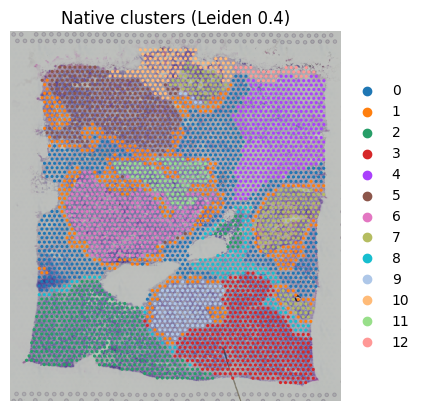

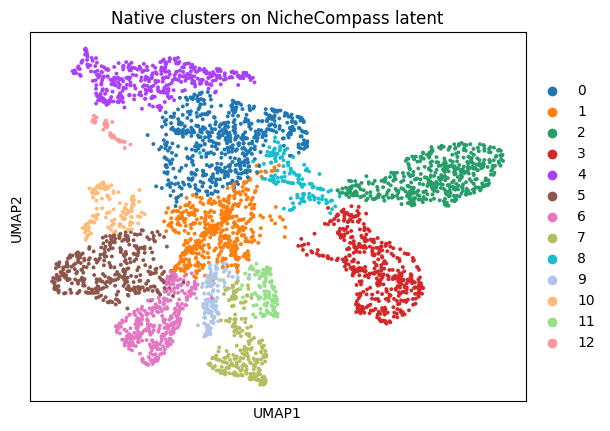

In [32]:
# ===================== Cell 6 =====================
# =========================================================
# 前置步骤：加载 Step3 保存的结果 (AnnData + 模型)
# =========================================================
import os
import scanpy as sc
# 假设 nichecompass 已正确导入为 nc
import nichecompass as nc 

# -------------------------- 1. 定义加载路径 (与保存路径完全一致) --------------------------
save_base_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260325"
file_prefix = "test_260325_02"

# -------------------------- 2. 加载 AnnData 对象 --------------------------
adata_load_path = os.path.join(save_base_dir, f"{file_prefix}.h5ad")
adata_model = sc.read_h5ad(adata_load_path)
print(f"✅ [1/2] AnnData 已从 {adata_load_path} 加载")

# -------------------------- 3. 加载 NicheCompass 模型 --------------------------
model_load_dir = os.path.join(save_base_dir, f"{file_prefix}_model")
# 注意：load 函数需要传入对应的 adata_model 以恢复图结构等信息
model = nc.models.NicheCompass.load(
    dir_path=model_load_dir,
    adata=adata_model
)
print(f"✅ [2/2] NicheCompass 模型已从 {model_load_dir} 加载")

# -------------------------- 4. 恢复/定义关键参数变量 (供后续代码使用) --------------------------
# 这些变量名必须与你训练时的代码保持一致
latent_key = "nichecompass_latent"

# ✅ 修复：动态检查 counts_key，不要硬编码
if "counts" in adata_model.layers:
    counts_key = "counts"
else:
    counts_key = None  # 如果 layers 里没有 counts，就设为 None (使用 .X)
    print("⚠️ 警告: 在 layers 中未找到 'counts'，将默认使用 adata_model.X")

adj_key = "spatial_connectivities"
node_batch_size = 128  # 与训练时保持一致

print("✅ 关键参数变量已恢复，可继续运行后续代码")



# =========================================================
# Step3: 训练后仅查看 NicheCompass 原生聚类结果（无二次划分）
# 直接接在 model.train(...) 后运行
# =========================================================

# 1) 提取 latent（与训练保持同一 counts_key / adj_key）
adata_model.obsm[latent_key] = model.get_latent_representation(
    adata=adata_model,
    counts_key=counts_key,
    adj_key=adj_key,
    node_batch_size=node_batch_size,
)

# 2) 官方教程风格：latent 上建图 + UMAP
sc.pp.neighbors(adata_model, use_rep=latent_key, key_added=latent_key)
sc.tl.umap(adata_model, neighbors_key=latent_key)

# 3) 原生聚类（不过度切碎）
native_cluster_key = "latent_leiden_0.4"
sc.tl.leiden(
    adata_model,
    neighbors_key=latent_key,
    key_added=native_cluster_key,
    resolution=0.4
)

print(f"✅ 原生聚类完成：{adata_model.obs[native_cluster_key].nunique()} 类")

# 4) 仅可视化原生聚类（空间 + UMAP）
sc.pl.spatial(
    adata_model,
    color=native_cluster_key,
    spot_size=170,
    title="Native clusters (Leiden 0.4)",
    frameon=False
)
sc.pl.umap(
    adata_model,
    color=native_cluster_key,
    title="Native clusters on NicheCompass latent"
)



阶段二：数据驱动的自适应阈值与代谢投影 (Data-Driven Projection)
step4——step5
先通过 NicheCompass 基于空间坐标构建组织的物理联通图，无监督学习生成微生态位基础骨架，锁定每个测序 spot 的真实空间邻居关系；
为每条代谢通讯轴计算空间耦合分数，结合 spot 自身的代谢发送能力与周边邻居的接收能力，量化真实的空间通讯潜力；
用高斯混合模型（GMM）为每条轴独立自适应设定活性阈值，分位数法兜底，再基于阈值完成微生态位的精准分型，对过渡区做后续空间拓扑优化；
最终通过分布可视化与空间置换检验，验证结果的生物学真实性与统计稳健性，排除随机噪音干扰。

=== 阶段二: 数据驱动的自适应阈值与代谢生态位初筛 ===
--> 1. 计算空间加权代谢通讯分数 (Coupling Score)...
--> 2. 学习每条代谢轴的自适应阈值 (GMM / Quantile)...


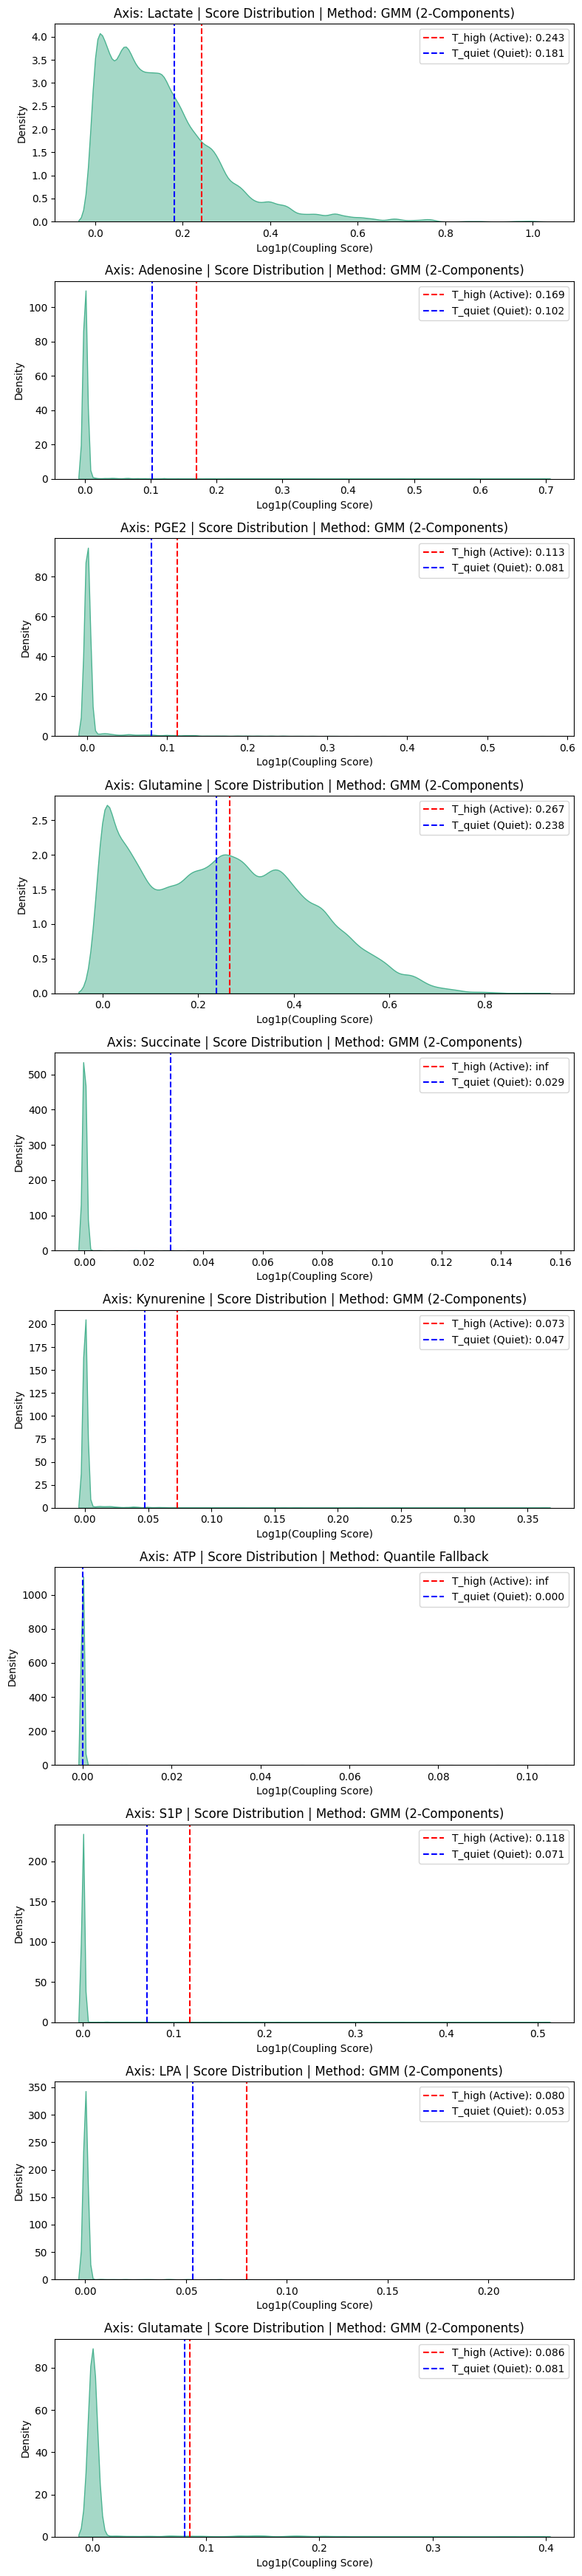


--- 自适应阈值计算结果 ---


,T_high,T_quiet,Method
Lactate,0.242729,0.180928,GMM (2-Components)
Adenosine,0.169026,0.10226,GMM (2-Components)
PGE2,0.113099,0.080617,GMM (2-Components)
Glutamine,0.26676,0.237518,GMM (2-Components)
Succinate,inf,0.029001,GMM (2-Components)
Kynurenine,0.072855,0.047314,GMM (2-Components)
ATP,inf,0.0,Quantile Fallback
S1P,0.117982,0.070534,GMM (2-Components)
LPA,0.080034,0.053389,GMM (2-Components)
Glutamate,0.08555,0.08144,GMM (2-Components)



--> 3. 统计微生态位特征，执行生物学标签映射 (全新容错与竞争逻辑)...

--- 微型生态位统计与标签判定表 ---


,Spot_Count,Initial_Label,Lactate_Active%,Adenosine_Active%,PGE2_Active%,Glutamine_Active%,Succinate_Active%,Kynurenine_Active%,ATP_Active%,S1P_Active%,LPA_Active%,Glutamate_Active%
Cluster_ID,,,,,,,,,,,,
0,596,Quiescent (Background),1.5,0.7,1.2,1.5,0.0,0.8,0.0,1.0,1.3,1.3
1,477,Single-axis: Glutamine,18.2,1.0,2.1,33.3,0.0,3.1,0.0,0.6,0.2,5.9
10,124,Quiescent (Background),21.0,0.0,0.8,8.9,0.0,0.8,0.0,0.0,0.0,0.8
11,108,Quiescent (Background),8.3,1.9,0.0,10.2,0.0,0.0,0.0,0.0,0.9,8.3
12,37,Quiescent (Background),0.0,0.0,0.0,0.0,0.0,2.7,0.0,0.0,0.0,0.0
2,469,Single-axis: Glutamine,13.4,1.9,1.9,82.7,0.0,0.0,0.0,0.2,0.2,14.7
3,423,Single-axis: Glutamine,14.4,0.0,12.8,78.5,0.0,0.5,0.0,0.0,0.2,9.5
4,389,Quiescent (Background),0.0,0.5,1.0,0.0,0.0,1.0,0.0,0.5,0.0,1.3
5,353,Single-axis: Glutamine,18.7,0.3,4.5,61.2,0.0,4.2,0.0,0.0,0.6,3.7



--> 4. 绘制初步判定的微环境空间地图...


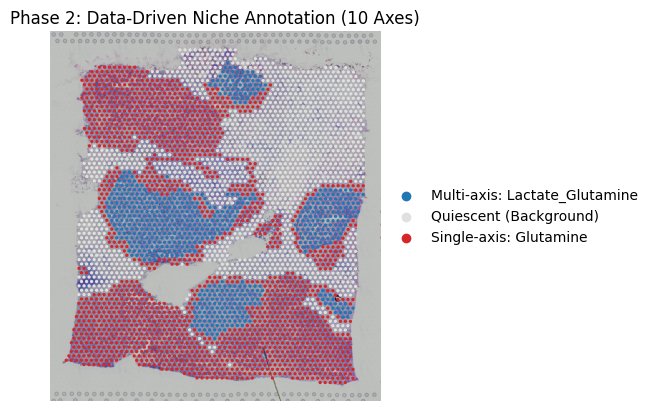

✅ 阶段二执行完毕！已定位出单轴区、多轴区、休眠区及待重塑的 Transitional 灰度区。


In [33]:
# =========================================================
# Cell 7: 空间通讯加权分数计算与生态位标注 (阶段二)
# =========================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.mixture import GaussianMixture
from IPython.display import display

print("=== 阶段二: 数据驱动的自适应阈值与代谢生态位初筛 ===")

# ---------------------------------------------------------
# Step 4.1: 构建空间感知的连续通讯分数 (Coupling Score)
# ---------------------------------------------------------
print("--> 1. 计算空间加权代谢通讯分数 (Coupling Score)...")
# 获取基于 squidpy 生成的空间物理邻接矩阵
adj_matrix = adata_model.obsp["spatial_connectivities"]

for k in AXES:
    sender_scores = adata_model.obs[f"{k}_Sender_Score"].values
    receiver_scores = adata_model.obs[f"{k}_Receiver_Score"].values
    
    # 核心公式: 自身 Sender * 周围所有物理邻居的 Receiver 之和
    neighbor_receiver_sum = adj_matrix.dot(receiver_scores)
    raw_coupling = sender_scores * neighbor_receiver_sum
    
    # 为了后续更好拟合高斯分布，对存在严重长尾的连乘分数进行 log1p 转换
    coupling_score = np.log1p(raw_coupling)
    adata_model.obs[f"Coupling_{k}"] = coupling_score

# ---------------------------------------------------------
# Step 4.2: 自适应混合阈值算法 (GMM + Quantile 兜底)
# ---------------------------------------------------------
print("--> 2. 学习每条代谢轴的自适应阈值 (GMM / Quantile)...")
thresholds_dict = {}

# 准备画图，将阈值切分可视化 (非常适合放入论文 Supplementary)
fig, axes = plt.subplots(len(AXES), 1, figsize=(8, 3.5 * len(AXES)))
if len(AXES) == 1: axes =[axes]

for idx, k in enumerate(AXES):
    scores = adata_model.obs[f"Coupling_{k}"].values
    
    # 提取非零有效值用于拟合 (去除纯背景底噪点的影响)
    scores_clean = scores[~np.isnan(scores) & (scores > 0)].reshape(-1, 1)
    
    t_high, t_quiet = None, None
    method_used = "Quantile Fallback"
    
    # -- 优先尝试 2-Component GMM --
    if len(scores_clean) > 50:  # 只有当非零点足够多才跑 GMM
        try:
            gmm = GaussianMixture(n_components=2, random_state=42)
            labels = gmm.fit_predict(scores_clean)
            
            m0, m1 = gmm.means_[0][0], gmm.means_[1][0]
            s0, s1 = np.sqrt(gmm.covariances_[0][0][0]), np.sqrt(gmm.covariances_[1][0][0])
            
            # 校验: 两个峰要有显著区分度 (均值差 > 1倍全局标准差)
            if abs(m0 - m1) > np.std(scores_clean):
                if m0 > m1:
                    t_high = np.min(scores_clean[labels == 0]) # 信号峰最小值
                    t_quiet = m1 + s1                          # 背景峰均值+1SD
                else:
                    t_high = np.min(scores_clean[labels == 1])
                    t_quiet = m0 + s0
                method_used = "GMM (2-Components)"
        except Exception as e:
            pass # 如果GMM不收敛或抛错，平滑过渡到底部分位数策略
            
    # -- 兜底策略: 分位数法 (q85 & q35) --
    if t_high is None:
        t_high = np.quantile(scores, 0.85)
        t_quiet = np.quantile(scores, 0.35)
    
    # 硬基线安全锁: 如果阈值算出来太低，说明全组织都没活化
    if t_high < 0.05:
        t_high = np.inf
        
    thresholds_dict[k] = {'T_high': t_high, 'T_quiet': t_quiet, 'Method': method_used}
    
    # 将 Spot 状态记录回 obs
    adata_model.obs[f"Active_{k}"] = (scores >= t_high).astype(int)
    adata_model.obs[f"Quiet_{k}"] = (scores <= t_quiet).astype(int)
    
    # 画密度分布及阈值线
    sns.kdeplot(scores, ax=axes[idx], fill=True, color="#4CB391", alpha=0.5, bw_adjust=0.5)
    axes[idx].axvline(t_high, color='red', linestyle='--', label=f'T_high (Active): {t_high:.3f}')
    axes[idx].axvline(t_quiet, color='blue', linestyle='--', label=f'T_quiet (Quiet): {t_quiet:.3f}')
    axes[idx].set_title(f"Axis: {k} | Score Distribution | Method: {method_used}")
    axes[idx].set_xlabel("Log1p(Coupling Score)")
    axes[idx].legend()

plt.tight_layout()
plt.show()

# 打印阈值结果表
df_thresholds = pd.DataFrame(thresholds_dict).T
print("\n--- 自适应阈值计算结果 ---")
display(df_thresholds)
# ---------------------------------------------------------
# Step 5: 微型生态位 (Micro-clusters) 统计判定与初标注
# ---------------------------------------------------------
print("\n--> 3. 统计微生态位特征，执行生物学标签映射 (全新容错与竞争逻辑)...")

cluster_annotations = {}
cluster_stats = []
native_clusters = adata_model.obs[native_cluster_key].unique()

# ==========================================
# 🔥 新增：在 adata.obs 中初始化各条轴的活跃比例列
# ==========================================
for k in AXES:
    adata_model.obs[f"{k}_Cluster_Active_Frac"] = 0.0

for c in sorted(native_clusters):
    c_mask = adata_model.obs[native_cluster_key] == c
    total_spots = c_mask.sum()
    
    active_fracs = {}
    quiet_fracs = {}
    
    # 统计本 cluster 在各条轴上的分布比例
    for k in AXES:
        active_fracs[k] = adata_model.obs.loc[c_mask, f"Active_{k}"].sum() / total_spots
        quiet_fracs[k] = adata_model.obs.loc[c_mask, f"Quiet_{k}"].sum() / total_spots
        
        # 🔥 新增：将计算出的比例实时保存到 adata.obs 的对应 Spot 中
        adata_model.obs.loc[c_mask, f"{k}_Cluster_Active_Frac"] = active_fracs[k]
        
    # --- 全新判定逻辑应用 ---
    # 1. 提取所有活跃比例 > 30% 的轴
    active_axes = [k for k, v in active_fracs.items() if v > 0.30]
    
    # 2. 判定 Quiescent 休眠生态位 (引入容错率)
    avg_quiet = np.mean(list(quiet_fracs.values()))
    max_active = np.max(list(active_fracs.values()))
    
    cond_a_quiescent = (avg_quiet > 0.60) and (max_active <= 0.20)
    count_dead_axes = sum(1 for k in AXES if quiet_fracs[k] > 0.60 and active_fracs[k] < 0.15)
    cond_b_quiescent = count_dead_axes >= 8
    
    is_quiescent = cond_a_quiescent or cond_b_quiescent
    
    # 3. 执行严格互斥判定
    if len(active_axes) == 1:
        c_label = f"Single-axis: {active_axes[0]}"
    elif len(active_axes) >= 2:
        # 🔥 修改：明确指出是哪几条轴混合 (例如: Multi-axis: Glutamine_Lactate)
        c_label = f"Multi-axis: {'_'.join(active_axes)}"
    elif is_quiescent:
        c_label = "Quiescent (Background)"
    else:
        c_label = "Transitional"
        
    cluster_annotations[c] = c_label
    
    # 保存统计数据用于查看
    stat_row = {'Cluster_ID': c, 'Spot_Count': total_spots, 'Initial_Label': c_label}
    for k in AXES: stat_row[f"{k}_Active%"] = round(active_fracs[k] * 100, 1)
    cluster_stats.append(stat_row)

# 将判定映射回 adata_model (供下一阶段拆分合并使用)
adata_model.obs["Niche_Annotation"] = adata_model.obs[native_cluster_key].map(cluster_annotations)

df_cluster_stats = pd.DataFrame(cluster_stats).set_index('Cluster_ID')
print("\n--- 微型生态位统计与标签判定表 ---")
display(df_cluster_stats)



# ---------------------------------------------------------
# 可视化: 初判后的空间生态位地图
# ---------------------------------------------------------
print("\n--> 4. 绘制初步判定的微环境空间地图...")

# ==============================
# 1. 扩充为 20 种高对比度离散颜色 (Tab20 经典色板)
# 足够应对 10 轴带来的十几种生态位类别
# ==============================
color_list =[
    "#d62728", "#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", 
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#ff9896", "#aec7e8", "#98df8a", "#ffbb78", "#c5b0d5", 
    "#c49c94", "#f7b6d2", "#c7c7c7", "#dbdb8d", "#9edae5"
]

# ==============================
# 2. 获取数据里的实际类别，并按顺序分配颜色
# ==============================
all_categories = adata_model.obs["Niche_Annotation"].unique().tolist()

# 强制将 Quiescent 和 Transitional 固定为不显眼的底色，让活跃轴更突出
custom_palette = {}
color_idx = 0

for cat in all_categories:
    if "Quiescent" in cat:
        custom_palette[cat] = "#e0e0e0"  # 浅灰色代表无代谢底噪
    elif "Transitional" in cat:
        custom_palette[cat] = "#ffe119"  # 亮黄色代表过渡交界区
    else:
        # 分配大色板中的颜色
        custom_palette[cat] = color_list[color_idx % len(color_list)]
        color_idx += 1

# ==============================
# 3. 画图
# ==============================
sc.pl.spatial(
    adata_model,
    color="Niche_Annotation",
    size=1, # 保持你修改后的 size=1 
    title="Phase 2: Data-Driven Niche Annotation (10 Axes)",
    frameon=False,
    palette=custom_palette
)
print("✅ 阶段二执行完毕！已定位出单轴区、多轴区、休眠区及待重塑的 Transitional 灰度区。")

可视化每个代谢轴的浓度梯度图


=== 附加分析: 生成十种代谢物空间通讯浓度梯度图 ===
注: 采用 Coupling_Score (Sender * 邻居Receiver) 作为有效代谢物浓度与作用场的推断指标


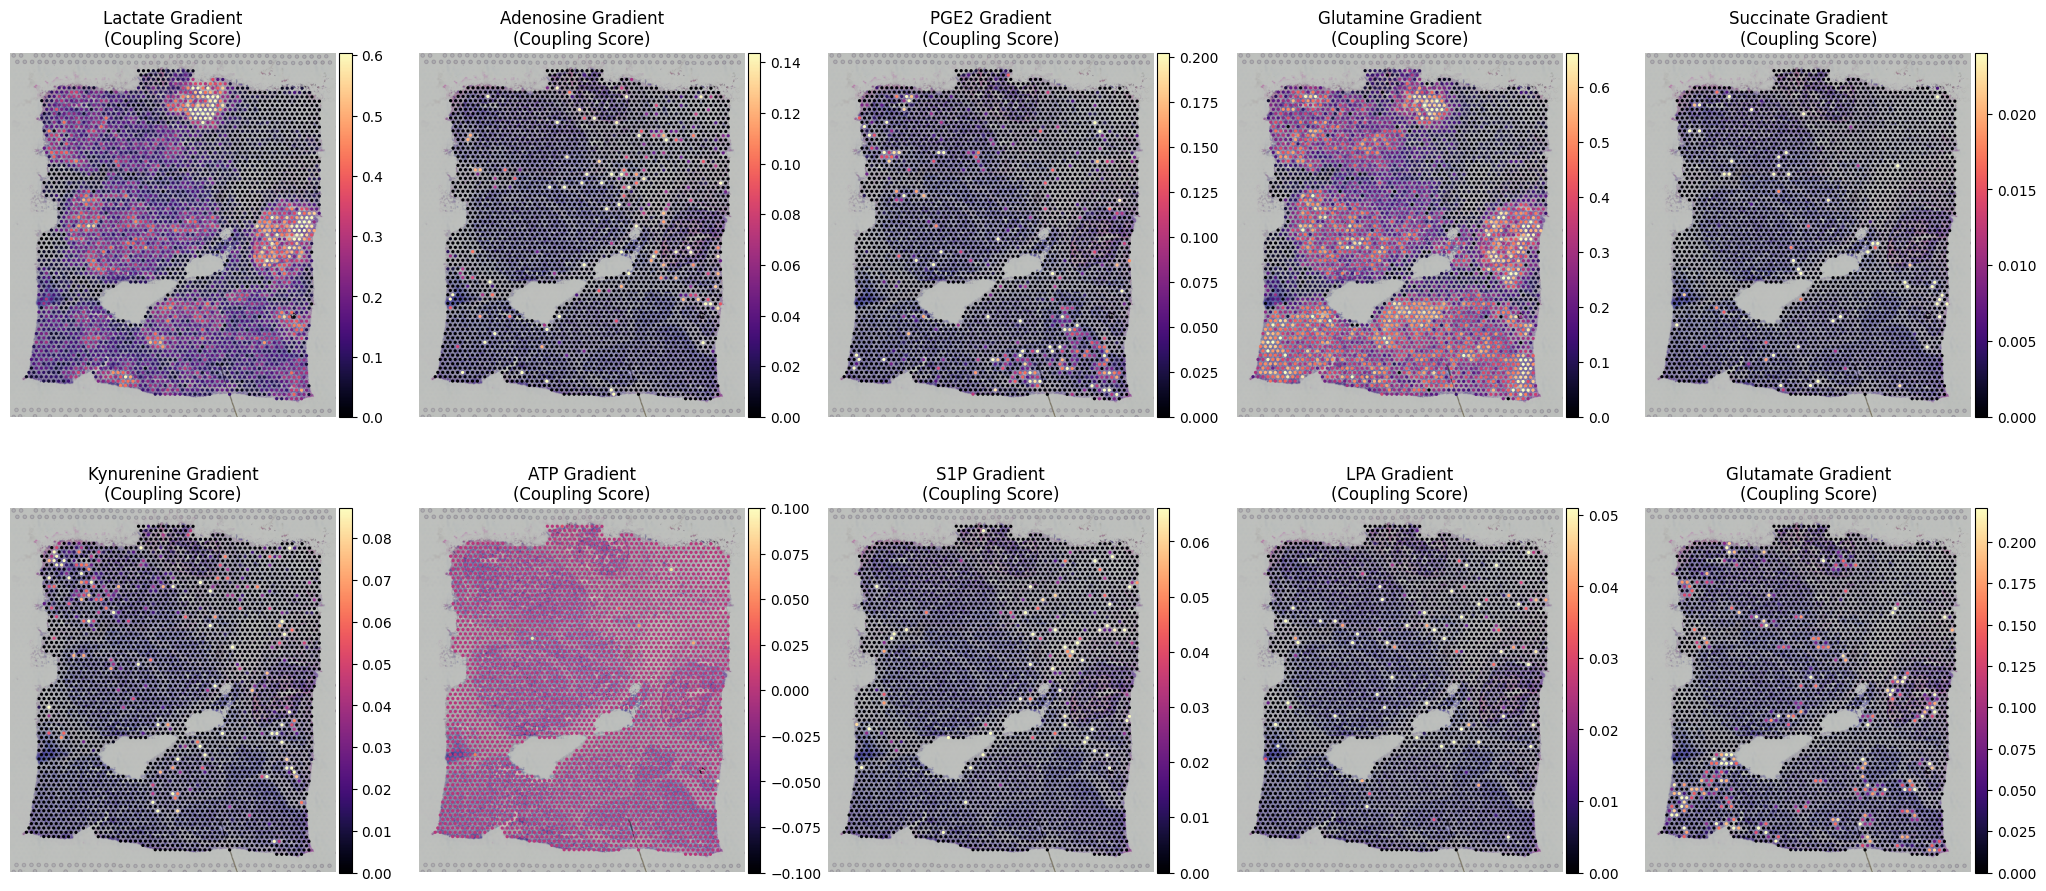

✅ 10 种代谢物的浓度梯度图绘制完毕！


In [34]:
# =========================================================
# Cell 8: 绘制 10 种代谢物的空间浓度梯度图 (连续分布)
# =========================================================
import matplotlib.pyplot as plt
import scanpy as sc

print("=== 附加分析: 生成十种代谢物空间通讯浓度梯度图 ===")
print("注: 采用 Coupling_Score (Sender * 邻居Receiver) 作为有效代谢物浓度与作用场的推断指标")

# 1. 获取需要绘制的列名 (Coupling_Score 已经在上一步取了 log1p，非常适合梯度可视化)
gradient_columns = [f"Coupling_{k}" for k in AXES]

# 2. 为每张图设置好标题
plot_titles =[f"{k} Gradient\n(Coupling Score)" for k in AXES]

# 3. 设置绘图参数
# 使用 'magma' 或 'inferno' 色系，这种暗底亮色的色谱非常适合展示类似“荧光染色”的浓度梯度
cmap_choice = "magma" 

# 4. 利用 scanpy 自带的多图排列功能绘制
sc.pl.spatial(
    adata_model,
    color=gradient_columns,
    cmap=cmap_choice,
    size=1,              # 保持与你前面一致的 spot 大小
    ncols=5,             # 每行放 5 张图，10 个轴正好 2 行
    frameon=False,       # 去掉坐标轴边框，更美观
    title=plot_titles,
    vmin=0,              # 浓度最低为 0
    vmax='p99',          # 截断最高 1% 的极端离群值，让主体梯度颜色更丰富
    show=False           # 先不显示，稍后通过 plt.show() 统一控制
)

# 调整子图间距并展示
plt.subplots_adjust(wspace=0.1, hspace=0.2)
fig = plt.gcf()
fig.set_size_inches(25, 10) # 设置大画布，保证高分辨率
plt.show()

print("✅ 10 种代谢物的浓度梯度图绘制完毕！")

阶段三  空间拓扑图剪枝与重塑 (Spatial Refinement: Split, Merge & Smooth)

=== 阶段三: 空间拓扑图剪枝与重塑 (Split, Merge & Smooth) ===
--> 1. Split (破): 正在探索 Transitional 过渡区内的高代谢连通子图...
    [Split] 成功从过渡区中抢救裂变出 0 个具有空间连通性的活跃 Spots。
--> 2. Merge (立): 正在跨物理空间合并功能同型的生态位...
    [Merge] 当前合并后的宏观生态位类型: ['TMCN_Quiescent', 'TMCN_Glutamine_Axis', 'TMCN_Lactate_Glutamine_Multi_Axis']
--> 3. Smooth (平滑): 强制注销极小碎片，并入邻接主力生态位...
    [Smooth] 扫描发现 52 个孤立噪音碎片 (面积 < 20)。
    [Smooth] 平滑去噪完成！所有连续性硬约束均满足。

--> 4. 绘制拓扑精修后的【最终代谢通讯生态位 (TMCN)】地图...


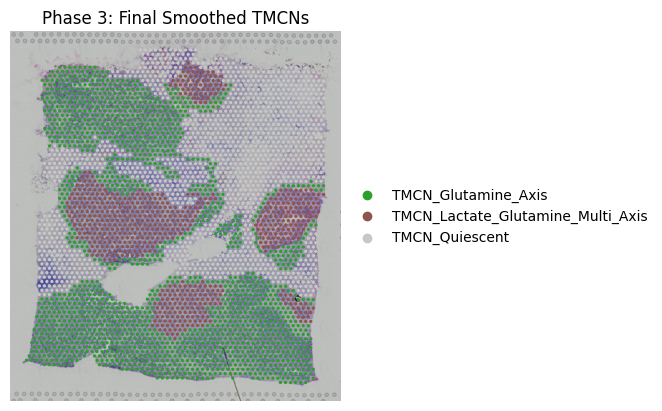

✅ 阶段三执行完毕！微型聚类已成功升维并重塑为宏观、空间连续的代谢通讯生态位。
✅ 已将包含 Final_Niche_Type 的结果保存至: /home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/Final_Hierarchical_Niches/Human_breast_cancer_ViHBC_NicheCompassAndmy_Final.h5ad


In [37]:
# =========================================================
# Cell 9: 空间拓扑图剪枝与重塑 (阶段三: Split, Merge & Smooth)
# =========================================================

import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt

print("=== 阶段三: 空间拓扑图剪枝与重塑 (Split, Merge & Smooth) ===")

# 初始化工作列
adata_model.obs["Niche_Type"] = adata_model.obs["Niche_Annotation"].astype(str)
adj = adata_model.obsp["spatial_connectivities"]

# ---------------------------------------------------------
# Step 6: Split（破）—— 图连通优先的异质区拆解
# ---------------------------------------------------------
print("--> 1. Split (破): 正在探索 Transitional 过渡区内的高代谢连通子图...")
min_cc_size = 20  
transitional_mask = (adata_model.obs["Niche_Type"] == "Transitional").values

tentative_labels = np.array([""] * adata_model.n_obs, dtype=object)
for i in range(adata_model.n_obs):
    if transitional_mask[i]:
        active_axes = [k for k in AXES if adata_model.obs[f"Active_{k}"].iloc[i] == 1]
        if len(active_axes) == 1:
            tentative_labels[i] = f"Single-axis: {active_axes[0]}"
        elif len(active_axes) > 1:
            # 🔥 修改：在拆分区域同样应用明确的多轴命名
            tentative_labels[i] = f"Multi-axis: {'_'.join(active_axes)}"
        else:
            tentative_labels[i] = "Transitional"

split_count = 0
for label in np.unique(tentative_labels):
    if not label or label == "Transitional":
        continue
    label_indices = np.where((tentative_labels == label) & transitional_mask)[0]
    if len(label_indices) == 0: continue
    sub_adj = adj[label_indices, :][:, label_indices]
    n_components, labels = sp.csgraph.connected_components(sub_adj, directed=False)
    counts = np.bincount(labels)
    valid_components = np.where(counts >= min_cc_size)[0]
    for comp in valid_components:
        comp_indices = label_indices[labels == comp]
        adata_model.obs.iloc[comp_indices, adata_model.obs.columns.get_loc("Niche_Type")] = label
        split_count += len(comp_indices)
print(f"    [Split] 成功从过渡区中抢救裂变出 {split_count} 个具有空间连通性的活跃 Spots。")

# ---------------------------------------------------------
# Step 7: Merge（立）—— 功能同型合并为宏观生态位
# ---------------------------------------------------------
print("--> 2. Merge (立): 正在跨物理空间合并功能同型的生态位...")
def map_niche_name(raw_name):
    if raw_name.startswith("Single-axis:"):
        axis = raw_name.split(": ")[1]
        return f"TMCN_{axis}_Axis"
    elif raw_name.startswith("Multi-axis:"):
        # 🔥 修改：将 "Multi-axis: Glutamine_Lactate" 转换为 "TMCN_Glutamine_Lactate_Multi_Axis"
        axes_str = raw_name.split(": ")[1]
        return f"TMCN_{axes_str}_Multi_Axis"
    elif raw_name.startswith("Quiescent"):
        return "TMCN_Quiescent"
    else:
        return "TMCN_Transitional"

adata_model.obs["Niche_Type"] = adata_model.obs["Niche_Type"].apply(map_niche_name)
print(f"    [Merge] 当前合并后的宏观生态位类型: {adata_model.obs['Niche_Type'].unique().tolist()}")




# ---------------------------------------------------------
# Step 8: 空间连续性硬约束（平滑去噪 Smooth）
# ---------------------------------------------------------
print("--> 3. Smooth (平滑): 强制注销极小碎片，并入邻接主力生态位...")
min_area_smooth = max(20, int(adata_model.n_obs * 0.005)) # 至少20个点，或0.5%总面积
niche_types = adata_model.obs["Niche_Type"].unique()
noise_mask = np.zeros(adata_model.n_obs, dtype=bool)

# 8.1: 全局扫描寻找碎片
for nt in niche_types:
    indices = np.where(adata_model.obs["Niche_Type"] == nt)[0]
    if len(indices) == 0: continue
    
    sub_adj = adj[indices, :][:, indices]
    n_components, labels = sp.csgraph.connected_components(sub_adj, directed=False)
    counts = np.bincount(labels)
    
    # 找到所有太小的孤立岛屿
    small_comps = np.where(counts < min_area_smooth)[0]
    for comp in small_comps:
        comp_indices = indices[labels == comp]
        noise_mask[comp_indices] = True

print(f"    [Smooth] 扫描发现 {noise_mask.sum()} 个孤立噪音碎片 (面积 < {min_area_smooth})。")

# 8.2: 依据“最大接触边数”进行邻域传播平滑 (KNN Label Propagation)
adata_model.obs["Final_Niche_Type"] = adata_model.obs["Niche_Type"].astype(str)
adata_model.obs.loc[noise_mask, "Final_Niche_Type"] = "Noise"

max_iter = 10
for iteration in range(max_iter):
    current_noise = (adata_model.obs["Final_Niche_Type"] == "Noise").values
    if not current_noise.any():
        break
        
    noise_indices = np.where(current_noise)[0]
    new_labels =[]
    
    for idx in noise_indices:
        # 获取该 spot 的所有物理邻居
        neighbors = adj[idx].indices
        neighbor_labels = adata_model.obs["Final_Niche_Type"].iloc[neighbors]
        valid_labels = neighbor_labels[neighbor_labels != "Noise"]
        
        if len(valid_labels) > 0:
            # 多数投票：并入周围最大的生态位
            new_labels.append(valid_labels.mode()[0])
        else:
            new_labels.append("Noise")
            
    adata_model.obs.iloc[noise_indices, adata_model.obs.columns.get_loc("Final_Niche_Type")] = new_labels

# 兜底：如果还有全是 Noise 组成的孤岛没被吞并，强制标记为休眠或过渡态
leftover = (adata_model.obs["Final_Niche_Type"] == "Noise").values
if leftover.sum() > 0:
    adata_model.obs.loc[leftover, "Final_Niche_Type"] = "TMCN_Transitional"

print("    [Smooth] 平滑去噪完成！所有连续性硬约束均满足。")

# ---------------------------------------------------------
# 可视化: 阶段三重塑后的最终生态位 (Final Niche Type)
# ---------------------------------------------------------
print("\n--> 4. 绘制拓扑精修后的【最终代谢通讯生态位 (TMCN)】地图...")

# 固定的基础配色字典
custom_palette = {
    "TMCN_Lactate_Axis": "#d62728",        
    "TMCN_Adenosine_Axis": "#1f77b4",      
    "TMCN_PGE2_Axis": "#ff7f0e",           
    "TMCN_Glutamine_Axis": "#2ca02c",      
    "TMCN_Succinate_Axis": "#9467bd",      
    "TMCN_Kynurenine_Axis": "#e377c2",     
    "TMCN_ATP_Axis": "#17becf",            
    "TMCN_S1P_Axis": "#7f7f7f",            
    "TMCN_LPA_Axis": "#ff9896",            
    "TMCN_Glutamate_Axis": "#fada5e",      
    "TMCN_Quiescent": "#c7c7c7",           
    "TMCN_Transitional": "#bcbd22"         
}

# 动态多轴备用颜色池（用于随机/顺序分配给生成的复合轴）
multi_axis_colors = ["#8c564b", "#8b008b", "#008080", "#ff1493", "#000080", "#ff8c00", "#4682b4", "#556b2f"]

final_categories = adata_model.obs["Final_Niche_Type"].unique().tolist()
active_palette = {}
color_idx = 0

# 🔥 修改：动态识别后缀为 _Multi_Axis 的类别，并为其分配颜色
for cat in final_categories:
    if cat in custom_palette:
        active_palette[cat] = custom_palette[cat]
    elif "Multi_Axis" in cat:
        active_palette[cat] = multi_axis_colors[color_idx % len(multi_axis_colors)]
        color_idx += 1
    else:
        active_palette[cat] = "#000000"

sc.pl.spatial(
    adata_model,
    color="Final_Niche_Type",
    size=1,
    title="Phase 3: Final Smoothed TMCNs",
    frameon=False,
    palette=active_palette
)
print("✅ 阶段三执行完毕！微型聚类已成功升维并重塑为宏观、空间连续的代谢通讯生态位。")




# =========================================================
# 保存包含 Final_Niche_Type 的结果
# =========================================================
save_base_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/Final_Hierarchical_Niches"
file_prefix = "Human_breast_cancer_ViHBC_NicheCompassAndmy_Final"

# 覆盖保存 h5ad (或者你可以存成一个新名字，比如 _processed.h5ad)
adata_save_path = os.path.join(save_base_dir, f"{file_prefix}.h5ad")
adata_model.write(adata_save_path)
print(f"✅ 已将包含 Final_Niche_Type 的结果保存至: {adata_save_path}")

结合SpaCET和我的结果
我现在有了我自己计算的Final_Niche_Type标签的结果和SpaCET得出的肿瘤非肿瘤区域划分标签结果，现在要把他们两个结合一下。
1、将SpaCET的Predicted_Tumor标签结果和我的非TMCN_Quiescent结果全都保留，合并到一起，这是一个肿瘤区域，其余区域，也就是将将SpaCET的Predicted_Non_Tumor标签结果和我的TMCN_Quiescent结果合并到一起形成一个Healthy非肿瘤区域。

2、在肿瘤区域中，将我的Final_Niche_Type标签中是单个代谢轴或者多个代谢轴的区域还是各自单独一个肿瘤标签（还是使用我的Final_Niche_Type标签的结果），将SpaCET的Predicted_Tumor标签结果和我得出的TMCN_Quiescent结果视作TMCN_Quiescent区域。

=== 阶段四: 跨模态标签联合 (Macro-Micro Hierarchical Niche) ===
--> 1. 正在加载并对齐数据...
    [对齐完成] 成功导入 SpaCET 预测标签: Unsupervised_Pred_0.53
--> 2. 正在执行宏观-微观联合推断逻辑...
    [逻辑应用完毕] 成功生成 Level1_Macro_Region 与 Level2_Micro_Niche。
--> 3. 正在生成最终层级空间生态位地图...


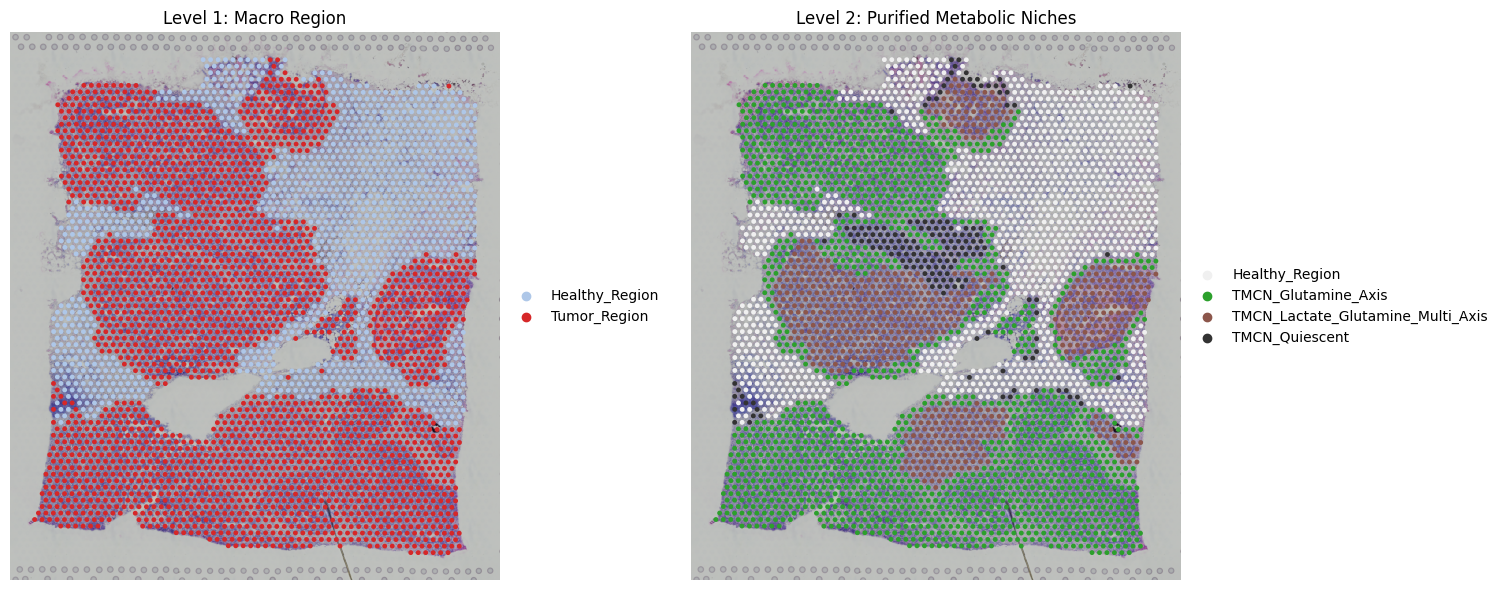


--> 4. 正在计算最终详细生态位的代谢轴高活性 Spot 比例...
✅ 各代谢轴突破高活性阈值的 spot 比例已保存至: 
   /home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/Final_Hierarchical_Niches/Level2_Micro_Niche_Active_Fractions.csv

--> 5. 正在精简 adata.obs 冗余中间特征，提取纯净版结果...
    [精简完成] 共移除了 65 个生化推断中间列。

🎉 终极纯净版数据已成功覆盖保存至原始文件:
   /home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_ViHBC_NicheCompassAndmy_Final.h5ad
📌 该最终 h5ad 文件的 adata.obs 中保留的列严格符合你的要求：
  1. 原始基础列及病理注释
  2. SpaCET 反卷积的所有细胞成分分数 (被永远合并在内了)
  3. 最终简略版生态位: 'Level1_Macro_Region' (Tumor/Healthy)
  4. 最终详细版生态位: 'Level2_Micro_Niche' (单轴/多轴/休眠等)


In [38]:
# =========================================================
# Cell 10: 跨模态标签对齐与最终层级生态位构建 (SpaCET + NicheCompass)
# =========================================================
import anndata as ad
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os

print("=== 阶段四: 跨模态标签联合 (Macro-Micro Hierarchical Niche) ===")

# ==========================================
# 1. 路径配置 (读取数据与设置输出)
# ==========================================
# 你的 NicheCompass 最终产物 (也就是我们要覆盖保存的原始文件)
path_h5ad_niche = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_ViHBC_NicheCompassAndmy_Final.h5ad"

# 你上一步保存的 SpaCET GMM 预测结果 CSV
path_spacet_csv = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/SpaCET/GMM_Tumor_NonTumor_Pred_Labels.csv"

# 指定输出文件夹（自动创建，用于存CSV和图片）
SAVE_DIR = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/Final_Hierarchical_Niches"
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# 2. 读取并合并数据
# ==========================================
print("--> 1. 正在加载并对齐数据...")
adata = ad.read_h5ad(path_h5ad_niche)
spacet_df = pd.read_csv(path_spacet_csv, index_col=0)

# 动态获取 GMM 预测的那一列的名字 (例如 'Unsupervised_Pred_0.45')
spacet_pred_col = [c for c in spacet_df.columns if c.startswith('Unsupervised_Pred_')][0]

# 合并到 adata.obs (利用索引自动对齐)
adata.obs = adata.obs.join(spacet_df[[spacet_pred_col]])
print(f"    [对齐完成] 成功导入 SpaCET 预测标签: {spacet_pred_col}")

# ==========================================
# 3. 严格执行核心合并规则 (并集逻辑)
# ==========================================
print("--> 2. 正在执行宏观-微观联合推断逻辑...")

# 初始化新列，默认全为健康区域
adata.obs['Level1_Macro_Region'] = 'Healthy_Region'
adata.obs['Level2_Micro_Niche'] = 'Healthy_Region'

# 提取关键判断条件
is_spacet_tumor = adata.obs[spacet_pred_col] == 'Predicted_Tumor'
is_niche_quiescent = adata.obs['Final_Niche_Type'] == 'TMCN_Quiescent'

# ----------------- 规则 1: Level 1 (Tumor vs Healthy) -----------------
# 将 (SpaCET预测为肿瘤) 和 (微环境不是休眠态) 合并(逻辑或 |)，合并后的区域就是肿瘤区域
tumor_mask = is_spacet_tumor | (~is_niche_quiescent)
adata.obs.loc[tumor_mask, 'Level1_Macro_Region'] = 'Tumor_Region'

# ----------------- 规则 2: Level 2 (微型代谢生态位) -----------------
# 1. 在肿瘤区域中，如果你的 Final_Niche_Type 不是休眠态(即单个或多个代谢轴)，直接使用你的结果
active_niche_mask = ~is_niche_quiescent
adata.obs.loc[active_niche_mask, 'Level2_Micro_Niche'] = adata.obs.loc[active_niche_mask, 'Final_Niche_Type']

# 2. 将 SpaCET 预测为 Tumor 且 你的结果为 TMCN_Quiescent 的区域，视作 TMCN_Quiescent
quiescent_tumor_mask = is_spacet_tumor & is_niche_quiescent
adata.obs.loc[quiescent_tumor_mask, 'Level2_Micro_Niche'] = 'TMCN_Quiescent'

print("    [逻辑应用完毕] 成功生成 Level1_Macro_Region 与 Level2_Micro_Niche。")

# ==========================================
# 4. 可视化检查
# ==========================================
print("--> 3. 正在生成最终层级空间生态位地图...")

macro_palette = {
    "Tumor_Region": "#d62728",    
    "Healthy_Region": "#aec7e8"   
}

base_micro_palette = {
    "TMCN_Lactate_Axis": "#d62728",        
    "TMCN_Adenosine_Axis": "#1f77b4",      
    "TMCN_PGE2_Axis": "#ff7f0e",           
    "TMCN_Glutamine_Axis": "#2ca02c",      
    "TMCN_Succinate_Axis": "#9467bd",      
    "TMCN_Kynurenine_Axis": "#e377c2",     
    "TMCN_ATP_Axis": "#17becf",            
    "TMCN_S1P_Axis": "#7f7f7f",            
    "TMCN_LPA_Axis": "#ff9896",            
    "TMCN_Glutamate_Axis": "#fada5e",      
    "TMCN_Transitional": "#bcbd22",
    "TMCN_Quiescent": "#333333",           
    "Healthy_Region": "#f0f0f0"            
}

multi_axis_colors = ["#8c564b", "#8b008b", "#008080", "#ff1493", "#000080", "#ff8c00", "#4682b4", "#556b2f"]

active_macro_colors = {k: macro_palette[k] for k in adata.obs['Level1_Macro_Region'].unique()}

active_micro_colors = {}
color_idx = 0
for cat in adata.obs['Level2_Micro_Niche'].unique():
    if cat in base_micro_palette:
        active_micro_colors[cat] = base_micro_palette[cat]
    elif "Multi_Axis" in cat:
        active_micro_colors[cat] = multi_axis_colors[color_idx % len(multi_axis_colors)]
        color_idx += 1
    else:
        active_micro_colors[cat] = "#000000"

fig, axs = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.spatial(adata, color='Level1_Macro_Region', size=1, title="Level 1: Macro Region", 
              palette=active_macro_colors, frameon=False, ax=axs[0], show=False)
sc.pl.spatial(adata, color='Level2_Micro_Niche', size=1, title="Level 2: Purified Metabolic Niches", 
              palette=active_micro_colors, frameon=False, ax=axs[1], show=False)
plt.tight_layout()
plt.show()

# ==========================================
# 5. 提取并保存：最终详细生态位 (Level 2) 各代谢轴高活性比例
# ==========================================
print("\n--> 4. 正在计算最终详细生态位的代谢轴高活性 Spot 比例...")

axes_active_cols = [c for c in adata.obs.columns if c.startswith("Active_")]
active_frac_df = adata.obs.groupby('Level2_Micro_Niche')[axes_active_cols].mean().reset_index()

rename_map = {c: c.replace("Active_", "active_fraction_") for c in axes_active_cols}
active_frac_df.rename(columns=rename_map, inplace=True)
active_frac_df.rename(columns={'Level2_Micro_Niche': 'Micro_Niche_Cluster'}, inplace=True)

fraction_csv_path = os.path.join(SAVE_DIR, "Level2_Micro_Niche_Active_Fractions.csv")
active_frac_df.to_csv(fraction_csv_path, index=False)
print(f"✅ 各代谢轴突破高活性阈值的 spot 比例已保存至: \n   {fraction_csv_path}")

# ==========================================
# 6. 精简 h5ad 文件，只保留目标核心列
# ==========================================
print("\n--> 5. 正在精简 adata.obs 冗余中间特征，提取纯净版结果...")

drop_keywords = [
    "Sender_Score", "Receiver_Score", "Coupling_", "Active_", "Quiet_", 
    "Cluster_Active_Frac", "nichecompass_", "latent_leiden", 
    "Pred_Threshold_", "Unsupervised_Pred_", "Niche_Annotation", 
    "Niche_Type", "Final_Niche_Type", "Ground_Truth"
]

cols_to_drop = []
for c in adata.obs.columns:
    if any(k in c for k in drop_keywords):
        cols_to_drop.append(c)

adata.obs.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"    [精简完成] 共移除了 {len(cols_to_drop)} 个生化推断中间列。")

# ==========================================
# 7. 【关键修改】覆盖保存回原 h5ad 文件
# ==========================================
# 直接使用开头加载的 path_h5ad_niche，不新建文件
adata.write_h5ad(path_h5ad_niche)

print(f"\n🎉 终极纯净版数据已成功覆盖保存至原始文件:\n   {path_h5ad_niche}")
print("======================================================")
print("📌 该最终 h5ad 文件的 adata.obs 中保留的列严格符合你的要求：")
print("  1. 原始基础列及病理注释")
print("  2. SpaCET 反卷积的所有细胞成分分数 (被永远合并在内了)")
print("  3. 最终简略版生态位: 'Level1_Macro_Region' (Tumor/Healthy)")
print("  4. 最终详细版生态位: 'Level2_Micro_Niche' (单轴/多轴/休眠等)")
print("======================================================")

计算ARI

In [25]:
# =========================================================
# Cell 11
# 我自己结果+SpaCET结合后的结果
# 计算ARI
# =========================================================
# ==========================================
# 6. 新增：基于病理注释 annot_type 计算 ARI 评估指标
# ==========================================
print("\n===== 开始计算肿瘤区域分割 ARI 评估 =====")
# 1. 真实标签映射（严格按照你的要求）
gt_map_int = {
    'Tumor': 1,
    'Invasive': 1,
    'Surrounding tumor': 0,
    'Healthy': 0
}

# 预测标签映射（我们生成的Level1宏观区域）
pred_map_int = {
    'Tumor_Region': 1,
    'Healthy_Region': 0
}

# 2. 生成整数标签（用于计算ARI）
gt_labels = adata.obs['annot_type'].map(gt_map_int).values
pred_labels = adata.obs['Level1_Macro_Region'].map(pred_map_int).values

# 3. 过滤无效值（NaN/缺失标签）
valid_mask = ~np.isnan(gt_labels)
gt_valid = gt_labels[valid_mask]
pred_valid = pred_labels[valid_mask]

# 4. 计算调整兰德指数 ARI
ari_score = adjusted_rand_score(gt_valid, pred_valid)

# 5. 输出评估结果
print(f"✅ 真实标签来源：annot_type 病理注释")
print(f"✅ 预测标签来源：Level1_Macro_Region 联合预测区域")
print(f"✅ 有效计算 Spot 数量：{len(gt_valid)}")
print(f"🎉 肿瘤/非肿瘤分割 ARI = {ari_score:.4f}")

print("\n🎉 全部整合流程完成！你的肿瘤微环境图谱现在既有宏观边界，又有高置信度的微观代谢细节！")
# ==========================================
# 新增：保存ARI结果为CSV文件
# ==========================================
# 指定保存路径
SAVE_DIR = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/Final_Hierarchical_Niches"
csv_save_path = os.path.join(SAVE_DIR, "ARI_Tumor_Segmentation_Result.csv")

# 构建评估结果表格
ari_result = pd.DataFrame({
    "Metric": ["Adjusted_Rand_Score", "Valid_Spot_Count", "Ground_Truth_Source", "Prediction_Source"],
    "Value": [
        round(ari_score, 4),
        len(gt_valid),
        "annot_type (Pathology Annotation)",
        "Level1_Macro_Region (SpaCET+NicheCompass)"
    ],
    "Description": [
        "肿瘤/非肿瘤区域分割ARI评估值",
        "参与ARI计算的有效Spot数量",
        "病理注释金标准标签",
        "跨模态联合预测的宏观区域标签"
    ]
})

# 保存CSV文件
ari_result.to_csv(csv_save_path, index=False, encoding="utf-8-sig")
print(f"\n✅ ARI评估结果已保存至：{csv_save_path}")

print("\n🎉 全部整合流程完成！你的肿瘤微环境图谱现在既有宏观边界，又有高置信度的微观代谢细节！")


===== 开始计算肿瘤区域分割 ARI 评估 =====
✅ 真实标签来源：annot_type 病理注释
✅ 预测标签来源：Level1_Macro_Region 联合预测区域
✅ 有效计算 Spot 数量：3798
🎉 肿瘤/非肿瘤分割 ARI = 0.5255

🎉 全部整合流程完成！你的肿瘤微环境图谱现在既有宏观边界，又有高置信度的微观代谢细节！

✅ ARI评估结果已保存至：/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/Final_Hierarchical_Niches/ARI_Tumor_Segmentation_Result.csv

🎉 全部整合流程完成！你的肿瘤微环境图谱现在既有宏观边界，又有高置信度的微观代谢细节！


In [14]:
# =========================================================
# 只有我自己结果的
# 仅计算 ARI + NMI - 极简版
# =========================================================
import os
import scanpy as sc
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# 1. 加载最终数据
adata_model = sc.read_h5ad("/home/zhangjunyi/xiangmu/nichecompass-main/datasets/Human_breast_cancer/Human_breast_cancer_ViHBC/Human_breast_cancer_ViHBC_NicheCompassAndmy_Final.h5ad")

# 2. 定义二分类映射
pathology_map = {
    'Invasive': 'Tumor', 'Tumor': 'Tumor',
    'Surrounding tumor': 'Non_Tumor', 'Healthy': 'Non_Tumor'
}
model_map = {
    'TMCN_Glutamine_Axis': 'Tumor', 'TMCN_Mixed_Axis': 'Tumor',
    'TMCN_Quiescent': 'Non_Tumor', 'TMCN_Transitional': 'Non_Tumor'
}

# 3. 数据处理
df = adata_model.obs[['annot_type', 'Final_Niche_Type']].dropna().copy()
df['y_true'] = df['annot_type'].map(pathology_map)
df['y_pred'] = df['Final_Niche_Type'].map(model_map)
df = df.dropna()

# 4. 计算核心指标
ari = adjusted_rand_score(df['y_true'], df['y_pred'])
nmi = normalized_mutual_info_score(df['y_true'], df['y_pred'])

# # 5. 按要求保存结果
# save_dir = "/home/zhangjunyi/xiangmu/nichecompass-main/outputs/Human_breast_cancer_ViHBC/zhibiao/my_and_NicheCompass"
# os.makedirs(save_dir, exist_ok=True)
# result = pd.DataFrame({
#     "Method": ["NicheCompass_Final"], 
#     "ARI": [ari],
#     "NMI": [nmi]
# })
# result.to_csv(os.path.join(save_dir, "NicheCompass_Final_ARI.csv"), index=False)

# 输出结果
print(f"✅ ARI 计算完成: {ari:.4f}")
print(f"✅ NMI 计算完成: {nmi:.4f}")
# print(f"✅ 文件已保存: {save_dir}/NicheCompass_Final_ARI.csv")

✅ ARI 计算完成: 0.4344
✅ NMI 计算完成: 0.3152
